In [1]:
import httpx
import numpy as np
import matplotlib.pyplot as plt
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ExpSineSquared, WhiteKernel

# --- GLOBAL BASE DEFAULTS (USD) ---
BASE_USD_COST_PER_PANEL = 250.0
BASE_USD_ELECTRICITY_RATE = 0.15
BASE_USD_SYSTEM_COST = 5000.0

async def get_localized_defaults(country_name: str) -> dict:
    target_currency = "USD"
    exchange_rate = 1.0

    async with httpx.AsyncClient() as client:
        try:
            if country_name and country_name.lower() not in ["united states", "usa", "us"]:
                country_res = await client.get(f"https://restcountries.com/v3.1/name/{country_name}")
                if country_res.status_code == 200:
                    currencies = country_res.json()[0].get("currencies", {})
                    if currencies:
                        target_currency = list(currencies.keys())[0]

            if target_currency != "USD":
                rates_res = await client.get("https://open.er-api.com/v6/latest/USD")
                if rates_res.status_code == 200:
                    exchange_rate = rates_res.json().get("rates", {}).get(target_currency, 1.0)
        except Exception as e:
            print(f"Localization failed, defaulting to USD: {e}")

    return {
        "currency": target_currency,
        "cost_per_panel": round(BASE_USD_COST_PER_PANEL * exchange_rate, 2),
        "electricity_rate": round(BASE_USD_ELECTRICITY_RATE * exchange_rate, 3),
        "system_cost": round(BASE_USD_SYSTEM_COST * exchange_rate, 2),
    }

# --- TESTING WITH PREDEFINED INPUT ---
country = "India"
local_defaults = await get_localized_defaults(country)
print(f"Localized Defaults for {country}:")
print(local_defaults)

Localized Defaults for India:
{'currency': 'INR', 'cost_per_panel': 23138.59, 'electricity_rate': 13.883, 'system_cost': 462771.86}


C:\Users\acer\Desktop\DroneVision2\venv\Lib\site-packages\sklearn\gaussian_process\kernels.py:450: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__k2__length_scale is close to the specified upper bound 100000.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(


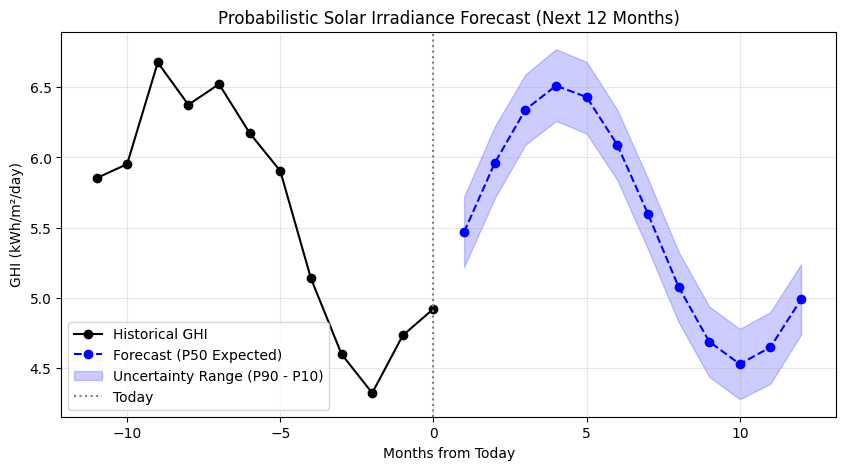

In [2]:
def forecast_ghi_probabilistic_gpr(historical_ghi_list, forecast_months=12):
    if len(historical_ghi_list) < 24:
        raise ValueError("Need at least 24 months of historical data to capture seasonality.")

    X_train = np.arange(len(historical_ghi_list)).reshape(-1, 1)
    y_train = np.array(historical_ghi_list)

    kernel = (
        1.0 * ExpSineSquared(length_scale=1.0, periodicity=12.0) * RBF(length_scale=50.0)
        + WhiteKernel(noise_level=0.1)
    )

    gpr = GaussianProcessRegressor(kernel=kernel, n_restarts_optimizer=5, normalize_y=True)
    gpr.fit(X_train, y_train)

    X_future = np.arange(len(historical_ghi_list), len(historical_ghi_list) + forecast_months).reshape(-1, 1)
    y_pred_mean, y_pred_std = gpr.predict(X_future, return_std=True)

    forecasts = []
    for i in range(forecast_months):
        mean_val = max(0, y_pred_mean[i])
        std_val = y_pred_std[i]
        
        forecasts.append({
            "month_offset": i + 1,
            "P50_expected": round(mean_val, 2),
            "P90_conservative": round(max(0, mean_val - 1.28 * std_val), 2),
            "P10_optimistic": round(mean_val + 1.28 * std_val, 2),
            "uncertainty_std": round(std_val, 3)
        })

    return forecasts

def plot_probabilistic_forecast(historical, forecasts):
    hist_len = len(historical)
    last_12_hist = historical[-12:] # Show only last year of history for clarity
    
    x_hist = np.arange(-11, 1)
    x_future = np.arange(1, len(forecasts) + 1)
    
    p50 = [f["P50_expected"] for f in forecasts]
    p90 = [f["P90_conservative"] for f in forecasts]
    p10 = [f["P10_optimistic"] for f in forecasts]

    plt.figure(figsize=(10, 5))
    plt.plot(x_hist, last_12_hist, label="Historical GHI", color="black", marker="o")
    plt.plot(x_future, p50, label="Forecast (P50 Expected)", color="blue", linestyle="--", marker="o")
    
    plt.fill_between(x_future, p90, p10, color="blue", alpha=0.2, label="Uncertainty Range (P90 - P10)")
    
    plt.axvline(x=0, color='gray', linestyle=':', label="Today")
    plt.title("Probabilistic Solar Irradiance Forecast (Next 12 Months)")
    plt.xlabel("Months from Today")
    plt.ylabel("GHI (kWh/m²/day)")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

# --- TESTING WITH PREDEFINED INPUT ---
# Simulating 60 months of historical GHI data for Chennai (oscillating between ~4.5 and 6.5)
time = np.arange(60)
simulated_chennai_ghi = 5.5 + np.sin(time * (2 * np.pi / 12)) + np.random.normal(0, 0.2, 60)
simulated_chennai_ghi = simulated_chennai_ghi.tolist()

forecast_results = forecast_ghi_probabilistic_gpr(simulated_chennai_ghi)
plot_probabilistic_forecast(simulated_chennai_ghi, forecast_results)

In [3]:
def predict_lifetime_generation(first_year_yield_kwh, lifespan_years=25, degradation_rate=0.006):
    lifetime_projection = []
    cumulative_yield = 0
    
    for year in range(1, lifespan_years + 1):
        current_year_yield = first_year_yield_kwh * ((1 - degradation_rate) ** (year - 1))
        cumulative_yield += current_year_yield
        
        lifetime_projection.append({
            "year": year,
            "projected_kwh": round(current_year_yield, 1)
        })
        
    return lifetime_projection, round(cumulative_yield, 1)

def predict_financial_savings(lifetime_projection, current_electricity_rate=0.15, grid_inflation_rate=0.03):
    lifetime_savings = []
    cumulative_savings = 0
    
    for data in lifetime_projection:
        year = data["year"]
        yield_kwh = data["projected_kwh"]
        
        future_rate = current_electricity_rate * ((1 + grid_inflation_rate) ** (year - 1))
        yearly_savings = yield_kwh * future_rate
        cumulative_savings += yearly_savings
        
        lifetime_savings.append({
            "year": year,
            "projected_kwh": yield_kwh, 
            "yearly_savings": round(yearly_savings, 2),
            "cumulative_savings": round(cumulative_savings, 2), 
            "electricity_rate_projected": round(future_rate, 3)
        })
        
    return lifetime_savings, round(cumulative_savings, 2)

def calculate_payback_period(lifetime_savings, system_cost):
    cumulative = 0
    for data in lifetime_savings:
        yearly = data.get("yearly_savings", 0)
        cumulative += yearly

        if cumulative >= system_cost:
            previous_cumulative = cumulative - yearly
            remaining_cost = system_cost - previous_cumulative

            if yearly <= 0: return None

            fraction_of_year = remaining_cost / yearly
            payback_years = data.get("year", 1) - 1 + fraction_of_year
            return round(payback_years, 1)

    return None 

def plot_roi_payback(lifetime_savings, system_cost, currency):
    years = [d["year"] for d in lifetime_savings]
    cumulative = [d["cumulative_savings"] for d in lifetime_savings]

    plt.figure(figsize=(10, 5))
    plt.plot(years, cumulative, label="Cumulative Savings", color="green", linewidth=2)
    plt.axhline(y=system_cost, color="red", linestyle="--", label=f"System Cost ({currency})")
    
    plt.title("Return on Investment & Payback Period")
    plt.xlabel("Years Active")
    plt.ylabel(f"Money ({currency})")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

print("Financial functions loaded.")

Financial functions loaded.


C:\Users\acer\Desktop\DroneVision2\venv\Lib\site-packages\sklearn\gaussian_process\kernels.py:450: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__k2__length_scale is close to the specified upper bound 100000.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(


--- FINAL SYSTEM REPORT ---
Expected First Year Generation: 7567.0 kWh
Conservative First Year Generation: 7222.0 kWh
Total Lifetime Savings: INR 3533989.92
Payback Period: 4.2 Years


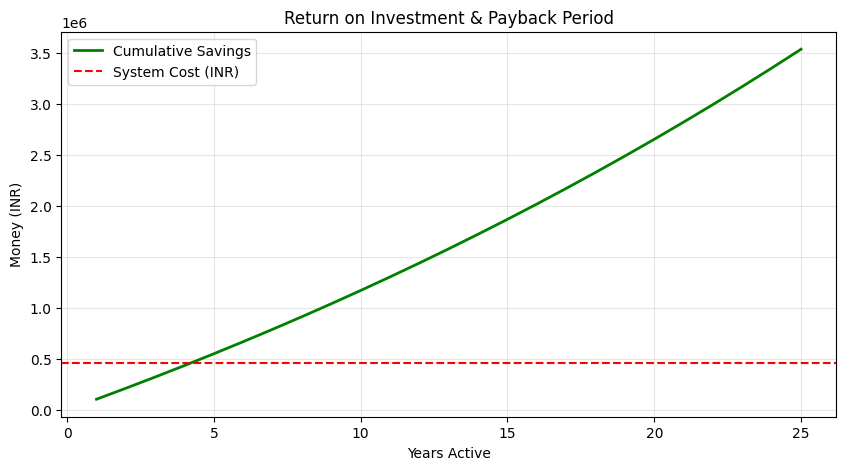

In [4]:
def generate_advanced_solar_report(historical_ghi_list, system_capacity_kw, system_cost, electricity_rate, currency="USD"):
    pr = 0.75 
    
    gpr_forecasts = forecast_ghi_probabilistic_gpr(historical_ghi_list, forecast_months=12)
    
    first_year_p50_ghi = sum([f["P50_expected"] for f in gpr_forecasts]) / 12
    first_year_p90_ghi = sum([f["P90_conservative"] for f in gpr_forecasts]) / 12
    
    p50_annual_yield = first_year_p50_ghi * 365 * system_capacity_kw * pr
    p90_annual_yield = first_year_p90_ghi * 365 * system_capacity_kw * pr
    
    lifetime_gen, total_lifetime_kwh = predict_lifetime_generation(p50_annual_yield)
    lifetime_savings, total_savings = predict_financial_savings(lifetime_gen, current_electricity_rate=electricity_rate)
    
    payback_years = calculate_payback_period(lifetime_savings, system_cost)
    
    return {
        "currency": currency,
        "advanced_metrics": {
            "first_year_yield_p50_kwh": round(p50_annual_yield, 0),
            "first_year_yield_p90_kwh": round(p90_annual_yield, 0),
            "lifetime_yield_kwh": total_lifetime_kwh,
            "total_estimated_savings": total_savings,
            "payback_period_years": payback_years
        },
        "lifetime_financial_projection": lifetime_savings
    }

# --- FINAL EXECUTION ---
# Using the localized defaults (INR) fetched in Part 1
system_capacity_kw = 5.0

final_report = generate_advanced_solar_report(
    historical_ghi_list=simulated_chennai_ghi, 
    system_capacity_kw=system_capacity_kw, 
    system_cost=local_defaults["system_cost"], 
    electricity_rate=local_defaults["electricity_rate"], 
    currency=local_defaults["currency"]
)

print("--- FINAL SYSTEM REPORT ---")
metrics = final_report["advanced_metrics"]
print(f"Expected First Year Generation: {metrics['first_year_yield_p50_kwh']} kWh")
print(f"Conservative First Year Generation: {metrics['first_year_yield_p90_kwh']} kWh")
print(f"Total Lifetime Savings: {final_report['currency']} {metrics['total_estimated_savings']}")
print(f"Payback Period: {metrics['payback_period_years']} Years")

# Draw the final Payback Period Chart
plot_roi_payback(final_report["lifetime_financial_projection"], local_defaults["system_cost"], local_defaults["currency"])